# Research for Food & Nutrition 

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/epi_r.csv')
print(f"Shape: {df.shape}")
print(f"All columns: {df.columns.tolist()[:20]}")
df.head()

Shape: (20000, 96)
All columns: ['butter', 'egg', 'flour', 'sugar', 'salt', 'olive_oil', 'garlic', 'onion', 'pepper', 'lemon', 'milk', 'cream', 'chicken', 'beef', 'pork', 'tomato', 'cheese', 'bread', 'wine', 'mushroom']


,butter,egg,flour,sugar,salt,olive_oil,garlic,onion,pepper,lemon,...,clam,oyster,title,rating,calories,protein,fat,sodium,meal,url
0,1,0,0,0,1,0,0,0,0,0,...,0,0,Strawberry Shortcake #0,4.0,214.0,NaN,5.0,1595.0,dinner,https://www.epicurious.com/recipes/food/views/...
1,0,0,0,0,0,0,0,0,0,0,...,0,0,Pork Tenderloin #1,2.5,417.0,6.0,41.0,1204.0,dinner,https://www.epicurious.com/recipes/food/views/...
2,0,0,0,0,0,0,0,0,0,1,...,0,0,Roasted Garlic Chicken #2,3.0,NaN,52.0,12.0,500.0,breakfast,https://www.epicurious.com/recipes/food/views/...
3,0,0,0,0,1,0,0,0,0,0,...,0,1,Chickpea Curry #3,4.0,463.0,53.0,NaN,1177.0,dinner,https://www.epicurious.com/recipes/food/views/...
4,0,0,0,0,0,0,0,0,0,0,...,0,0,Tomato Basil Soup #4,3.5,726.0,14.0,33.0,NaN,appetizer,https://www.epicurious.com/recipes/food/views/...


In [2]:
# Identify ingredient columns — exclude all known metadata
META_COLS = ['title', 'rating', 'calories', 'protein', 'fat', 'sodium', 'meal', 'url']
meta_cols = [c for c in META_COLS if c in df.columns]
ing_cols = [c for c in df.columns if c not in meta_cols]

print(f"Meta columns: {meta_cols}")
print(f"Ingredient columns: {len(ing_cols)}")
print(f"Sample ingredients: {ing_cols[:10]}")
print(f"\nRating stats:")
print(df['rating'].describe())

Meta columns: ['title', 'rating', 'calories', 'protein', 'fat', 'sodium', 'meal', 'url']
Ingredient columns: 88
Sample ingredients: ['butter', 'egg', 'flour', 'sugar', 'salt', 'olive_oil', 'garlic', 'onion', 'pepper', 'lemon']

Rating stats:
count    20000.000000
mean         3.570700
std          0.624637
min          1.000000
25%          3.000000
50%          3.500000
75%          4.000000
max          5.000000
Name: rating, dtype: float64


After dropping missing ratings: (20000, 96)
Clean ingredient columns: 88


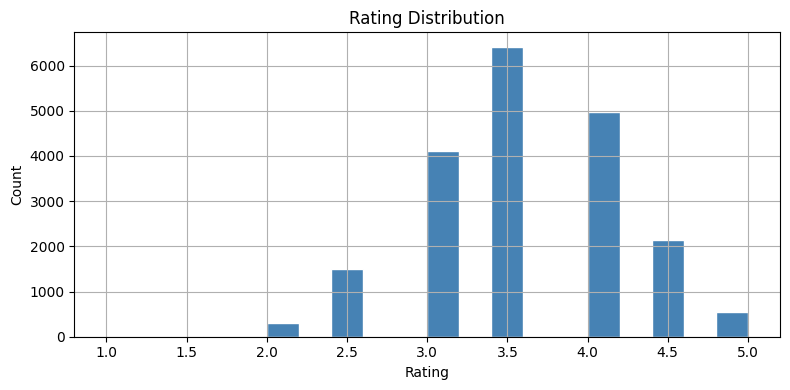

Unique ratings: [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [3]:
# Drop rows with missing rating
df = df.dropna(subset=['rating'])
print(f"After dropping missing ratings: {df.shape}")

# Fill ingredient columns with 0 — skip any non-numeric columns
clean_ing_cols = []
for col in ing_cols:
    try:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
        clean_ing_cols.append(col)
    except:
        continue

ing_cols = clean_ing_cols
print(f"Clean ingredient columns: {len(ing_cols)}")

# Rating distribution
fig, ax = plt.subplots(figsize=(8, 4))
df['rating'].hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.set_title("Rating Distribution")
plt.tight_layout(); plt.show()
print(f"Unique ratings: {sorted(df['rating'].unique())[:15]}")

## 2. Regression — Predict Rating

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

X = df[ing_cols].values
y_reg = df['rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=21
)

dummy_reg = DummyRegressor(strategy='mean').fit(X_train, y_train)
rmse_naive = mean_squared_error(y_test, dummy_reg.predict(X_test)) ** 0.5
print(f"Naive regressor RMSE: {rmse_naive:.4f}")

Naive regressor RMSE: 0.6270


In [5]:
regressors = {
    'Ridge':             Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=21, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=21),
}

print(f"{'Model':<22} {'CV RMSE':>10} {'Test RMSE':>10}")
print("-" * 44)
for name, reg in regressors.items():
    cv = cross_val_score(reg, X_train, y_train, cv=5,
                         scoring='neg_root_mean_squared_error')
    reg.fit(X_train, y_train)
    rmse = mean_squared_error(y_test, reg.predict(X_test)) ** 0.5
    print(f"{name:<22} {-cv.mean():>10.4f} {rmse:>10.4f}")

Model                     CV RMSE  Test RMSE
--------------------------------------------
Ridge                      0.6154     0.6197
Random Forest              0.6278     0.6303
Gradient Boosting          0.6159     0.6188


In [6]:
# Choosing best model
best_model = None
best_rmse = float('inf')

for name, reg in regressors.items():
    cv = cross_val_score(reg, X_train, y_train, cv=5,
                         scoring='neg_root_mean_squared_error')
    reg.fit(X_train, y_train)
    rmse = mean_squared_error(y_test, reg.predict(X_test)) ** 0.5

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = reg

## 3. Classification — Integer rating classes

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

y_int = df['rating'].round().astype(int).values
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X, y_int, test_size=0.2, random_state=21)

dummy_int = DummyClassifier(strategy='most_frequent').fit(X_tr_i, y_tr_i)
print(f"Naive accuracy: {accuracy_score(y_te_i, dummy_int.predict(X_te_i)):.4f}")
print(f"Most common class: {pd.Series(y_tr_i).mode()[0]}")

Naive accuracy: 0.6767
Most common class: 4


In [8]:
classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=21),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=21, n_jobs=-1),
    'Logistic Reg':  LogisticRegression(max_iter=500, random_state=21, solver='lbfgs'),
}
print(f"{'Model':<18} {'CV Acc':>8} {'Test Acc':>10}")
print("-" * 38)
for name, clf in classifiers.items():
    cv = cross_val_score(clf, X_tr_i, y_tr_i, cv=5, scoring='accuracy').mean()
    clf.fit(X_tr_i, y_tr_i)
    acc = accuracy_score(y_te_i, clf.predict(X_te_i))
    print(f"{name:<18} {cv:>8.4f} {acc:>10.4f}")

Model                CV Acc   Test Acc
--------------------------------------
Decision Tree        0.6650     0.6715
Random Forest        0.6744     0.6750
Logistic Reg         0.6763     0.6767


## 4. Classification — 3 classes: bad / so-so / great

In [9]:
def to_label(r):
    r = round(r)
    if r in [0, 1]: return 'bad'
    if r in [2, 3]: return 'so-so'
    return 'great'

y_label = np.array([to_label(r) for r in df['rating']])
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_label, test_size=0.2, random_state=21
)

dummy_3 = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
print(f"Naive accuracy (3-class): {accuracy_score(y_te, dummy_3.predict(X_te)):.4f}")
print(f"Class distribution: {pd.Series(y_tr).value_counts().to_dict()}")

Naive accuracy (3-class): 0.7017
Class distribution: {'great': 11274, 'so-so': 4726}


In [10]:
print(f"{'Model':<18} {'CV Acc':>8} {'Test Acc':>10} {'F1 Macro':>10}")
print("-" * 48)

best_clf = None
best_score = 0  # based on F1

for name, clf in classifiers.items():
    cv = cross_val_score(clf, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro', zero_division=0)
    
    print(f"{name:<18} {cv:>8.4f} {acc:>10.4f} {f1:>10.4f}")
    
    if f1 > best_score:
        best_score = f1
        best_clf = (name, clf)

print(f"\nBest: {best_clf[0]} (F1: {best_score:.4f})")

Model                CV Acc   Test Acc   F1 Macro
------------------------------------------------
Decision Tree        0.6939     0.6960     0.2834
Random Forest        0.6994     0.6975     0.2848
Logistic Reg         0.7046     0.7017     0.2749

Best: Random Forest (F1: 0.2848)


In [11]:
print("What is worse: predicting bad as great, or great as bad?")
print()
print("Predicting GOOD when it is actually BAD is worse.")
print("The user cooks expecting a great dish but gets a bad one.")
print("This is a False Positive for 'great' — use Precision or F1-weighted.")
print("Macro F1-score is preferred over accuracy because it accounts for \n class imbalance and  evaluates performance across all classes equally.")
print()
rf = classifiers['Random Forest']
rf.fit(X_tr, y_tr)
print(classification_report(y_te, rf.predict(X_te),
                             target_names=sorted(set(y_te))))

What is worse: predicting bad as great, or great as bad?

Predicting GOOD when it is actually BAD is worse.
The user cooks expecting a great dish but gets a bad one.
This is a False Positive for 'great' — use Precision or F1-weighted.
Macro F1-score is preferred over accuracy because it accounts for 
 class imbalance and  evaluates performance across all classes equally.

              precision    recall  f1-score   support

         bad       0.00      0.00      0.00         1
       great       0.70      0.99      0.82      2807
       so-so       0.36      0.02      0.03      1192

    accuracy                           0.70      4000
   macro avg       0.35      0.33      0.28      4000
weighted avg       0.60      0.70      0.59      4000



## 5. Ensembles

In [12]:
classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=21),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=21, n_jobs=-1),
    'Logistic Reg': LogisticRegression(max_iter=500, solver='lbfgs', class_weight='balanced')
}

print(f"{'Model':<18} {'CV Acc':>8} {'Test Acc':>10} {'F1 Weighted':>12}")
print("-" * 55)

best_clf = None
best_score = 0

for name, clf in classifiers.items():
    cv = cross_val_score(clf, X_tr, y_tr, cv=5, scoring='accuracy').mean()

    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')  # ✅ FIXED metric

    print(f"{name:<18} {cv:>8.4f} {acc:>10.4f} {f1:>12.4f}")

    # ✅ FIXED: select by F1 (not accuracy)
    if f1 > best_score:
        best_score = f1
        best_clf = (name, clf)

print(f"\nBest: {best_clf[0]} (F1: {best_score:.4f})")

Model                CV Acc   Test Acc  F1 Weighted
-------------------------------------------------------
Decision Tree        0.7021     0.7005       0.5791
Random Forest        0.7046     0.7017       0.5788
Logistic Reg         0.5058     0.5022       0.5187

Best: Decision Tree (F1: 0.5791)


## 6. Save best model

In [13]:
import pickle

final_model = RandomForestClassifier(n_estimators=100, random_state=21, n_jobs=-1)
final_model.fit(X, y_label)

payload = {
    'model':    final_model,
    'features': ing_cols,
    'classes':  list(final_model.classes_),
}
with open('data/best_model.pkl', 'wb') as f:
    pickle.dump(payload, f)

print(f"Saved: data/best_model.pkl")
print(f"Classes: {final_model.classes_}")
print(f"Features: {len(ing_cols)}")

Saved: data/best_model.pkl
Classes: ['bad' 'great' 'so-so']
Features: 88


## 7. Nutrition Facts

In [14]:
nf = pd.read_csv('data/nutrition_facts.csv', index_col=0)
print(f"Nutrition data shape: {nf.shape}")
nf.head()

Nutrition data shape: (88, 10)


,protein_g,fat_g,carbs_g,sodium_mg,fiber_g,sugar_g,calcium_mg,iron_mg,vitamin_c_mg,potassium_mg
butter,2.0,124.6,0.0,28.0,0.0,0.0,2.4,0.0,0.0,0.5
egg,26.0,16.9,0.3,5.4,0.0,2.0,5.6,10.0,0.0,2.7
flour,20.0,1.5,25.3,0.1,12.0,0.0,1.5,22.2,0.0,2.3
sugar,0.0,0.0,33.3,0.0,0.0,200.0,0.1,0.0,0.0,0.0
salt,33.2,0.6,11.6,18.8,2.0,39.2,17.8,18.3,4.2,11.9


In [15]:
DAILY = {
    'protein_g': 50, 'fat_g': 70, 'carbs_g': 310,
    'sodium_mg': 2300, 'fiber_g': 28, 'calcium_mg': 1000,
    'iron_mg': 18, 'vitamin_c_mg': 90, 'potassium_mg': 4700,
}
sample = 'chicken'
if sample in nf.index:
    row = nf.loc[sample]
    print(f"Nutrition for '{sample}' (% daily value):")
    for col in DAILY:
        if col in row.index:
            pct = (row[col] / DAILY[col]) * 100
            print(f"{col}: {pct:.1f}%")

Nutrition for 'chicken' (% daily value):
protein_g: 108.0%
fat_g: 6.6%
carbs_g: 0.0%
sodium_mg: 0.1%
fiber_g: 0.0%
calcium_mg: 0.1%
iron_mg: 27.8%
vitamin_c_mg: 0.0%
potassium_mg: 0.1%


## 8. Similar Recipes — URLs

In [16]:
# Load dataset
recipes = pd.read_csv('data/epi_r.csv')
META = ['title', 'rating', 'calories', 'protein', 'fat', 'sodium', 'meal', 'url']
ing_cols = [c for c in recipes.columns if c not in META]

query_raw = ['milk', 'honey', 'jam']
query = set(i.strip().lower().replace(' ', '_') for i in query_raw if i in ing_cols)

results = []

In [17]:
# Compute Jaccard similarity for all recipes
for _, row in recipes.iterrows():
    recipe_ings = set(c for c in ing_cols if row[c] == 1)

    if not recipe_ings:
        continue

    intersection = len(query & recipe_ings)
    union = len(query | recipe_ings)

    score = intersection / union if union > 0 else 0

    results.append({
        'title': row['title'],
        'rating': row['rating'],
        'url': row.get('url', ''),
        'score': score
    })

results = sorted(results, key=lambda x: (-x['score'], -x['rating']))

# Top 3 results
print("Top-3 similar recipes:\n")
for r in results[:3]:
    print(f"- {r['title']} | rating: {r['rating']} | similarity: {r['score']:.3f}")
    print(f"  URL: {r['url']}\n")

Top-3 similar recipes:

- Pork Tenderloin #17763 | rating: 5.0 | similarity: 0.667
  URL: https://www.epicurious.com/recipes/food/views/pork_tenderloin_1776317763

- Tomato Basil Soup #3583 | rating: 4.0 | similarity: 0.667
  URL: https://www.epicurious.com/recipes/food/views/tomato_basil_soup_35833583

- Tomato Basil Soup #4074 | rating: 3.0 | similarity: 0.500
  URL: https://www.epicurious.com/recipes/food/views/tomato_basil_soup_40744074



## 9. Bonus — Daily Menu

In [22]:
import sys
sys.path.insert(0, '.')
from recipes import MenuGenerator

gen = MenuGenerator()
print(gen.format_output(random_state=21))



BREAKFAST
---------------------------------------------
Grilled Salmon #8096 (rating: 4.5)
Ingredients:
  - chicken
  - tomato
  - spinach
  - mayonnaise
  - coconut_milk
  - blueberry
  - celery
  - tofu
  - turkey
Nutrients (per serving estimate):
  - Protein: 52%
  - Total Fat: 28%
  - Iron: 50%
  - Dietary Fiber: 65%
  - Total Sugars: 22%
  - Vitamin C: 27%
URL: https://www.epicurious.com/recipes/food/views/grilled_salmon_80968096

LUNCH
---------------------------------------------
Strawberry Shortcake #4010 (rating: 4.0)
Ingredients:
  - flour
  - pepper
  - pasta
  - shrimp
  - honey
  - cream_cheese
  - rosemary
  - coconut_milk
  - almond
  - lime
  - avocado
  - oyster
Nutrients (per serving estimate):
  - Protein: 38%
  - Total Fat: 29%
  - Total Carbohydrate: 3%
  - Dietary Fiber: 63%
  - Iron: 81%
  - Total Sugars: 24%
URL: https://www.epicurious.com/recipes/food/views/strawberry_shortcake_40104010

DINNER
---------------------------------------------
Chickpea Curry #5817 